In [1]:
import subprocess
subprocess.run(['pip', 'install', 'shap', '-q'])
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.50.0


In [2]:
import os, pickle, json, warnings
import numpy as np
import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_MAP   = {'Low': 0, 'Medium': 1, 'High': 2}
WINDOW_SIZE = 30
N_FEATURES  = 8
OUT_DIR     = '/kaggle/working'

FEATURE_NAMES = [
    'l_knee_angle', 'r_knee_angle', 'l_hip_angle', 'r_hip_angle',
    'trunk_lean', 'asymmetry', 'l_knee_vel', 'r_knee_vel'
]

In [3]:
class ACLRiskLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return self.classifier(context)

In [4]:
CKPT_PATH = '/kaggle/input/datasets/haruxo/lstm-model/acl_risk_model_phase6.pt'
# Adjust the path above to wherever you saved best_acl_lstm.pt

model = ACLRiskLSTM().to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print("Checkpoint loaded. Best Val F1:", ckpt.get('best_val_f1', 'N/A'))

Checkpoint loaded. Best Val F1: 0.9878493339767577


In [5]:
TRAIN_PKL = '/kaggle/input/datasets/haruxo/phase-5-output/train_samples.pkl'
VAL_PKL   = '/kaggle/input/datasets/haruxo/phase-5-output/val_samples.pkl'

with open(TRAIN_PKL, 'rb') as f:
    train_samples = pickle.load(f)
with open(VAL_PKL, 'rb') as f:
    val_samples = pickle.load(f)

print(f"Train: {len(train_samples)}, Val: {len(val_samples)}")

Train: 1798545, Val: 76832


In [6]:
def flat_predict(X_flat):
    """
    X_flat : np.ndarray of shape (N, 240)  — N samples, each 30*8 flattened
    Returns : np.ndarray of shape (N, 3)   — softmax probabilities
    """
    X_3d = X_flat.reshape(-1, WINDOW_SIZE, N_FEATURES)   # (N, 30, 8)
    tensor = torch.tensor(X_3d, dtype=torch.float32).to(DEVICE)
    
    with torch.no_grad():
        logits = model(tensor)                            # (N, 3)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

In [7]:
test_input = np.zeros((5, 240))
test_output = flat_predict(test_input)
print("Output shape:", test_output.shape)   # Should print (5, 3)
assert test_output.shape == (5, 3), "flat_predict broken!"
print("flat_predict OK")

Output shape: (5, 3)
flat_predict OK


In [8]:
# --- Background: 200 High Risk training samples, flattened to (200, 240)
high_train = [s for s in train_samples if s['label'] == 'High']
print(f"High Risk train samples available: {len(high_train)}")

np.random.seed(SEED)
bg_samples = np.random.choice(len(high_train), size=min(200, len(high_train)), replace=False)
background = np.array([high_train[i]['features'].flatten() for i in bg_samples])
print("Background shape:", background.shape)   # (200, 240)

# --- Test: 20 High Risk validation samples
high_val = [s for s in val_samples if s['label'] == 'High']
print(f"High Risk val samples available: {len(high_val)}")

test_idx     = np.random.choice(len(high_val), size=min(20, len(high_val)), replace=False)
test_samples_flat = np.array([high_val[i]['features'].flatten() for i in test_idx])
print("Test shape:", test_samples_flat.shape)  # (20, 240)

High Risk train samples available: 597495
Background shape: (200, 240)
High Risk val samples available: 25524
Test shape: (20, 240)


In [9]:
print("Building KernelExplainer (this may take 1-2 minutes)...")
explainer = shap.KernelExplainer(flat_predict, background[:50])
print("KernelExplainer ready.")

Building KernelExplainer (this may take 1-2 minutes)...
KernelExplainer ready.


In [10]:
print("Computing SHAP values for 20 High Risk test samples...")
print("Expected time: 20-40 minutes. Do not interrupt.")

shap_values = explainer.shap_values(test_samples_flat, nsamples=100)

# shap_values is a list of 3 arrays, one per class
# Each array shape: (20, 240)
print(f"Number of SHAP output arrays: {len(shap_values)}")
print(f"Shape of each array: {shap_values[0].shape}")

Computing SHAP values for 20 High Risk test samples...
Expected time: 20-40 minutes. Do not interrupt.


  0%|          | 0/20 [00:00<?, ?it/s]

Number of SHAP output arrays: 20
Shape of each array: (240, 3)


In [11]:
# Use index 2 → High Risk class
shap_high = shap_values[2]                                         # (20, 240)
shap_3d   = shap_high.reshape(-1, WINDOW_SIZE, N_FEATURES)         # (20, 30, 8)

# Mean absolute SHAP value per frame per feature
mean_shap = np.mean(np.abs(shap_3d), axis=0)                       # (30, 8)
print("Mean SHAP matrix shape:", mean_shap.shape)                  # (30, 8)

Mean SHAP matrix shape: (30, 8)


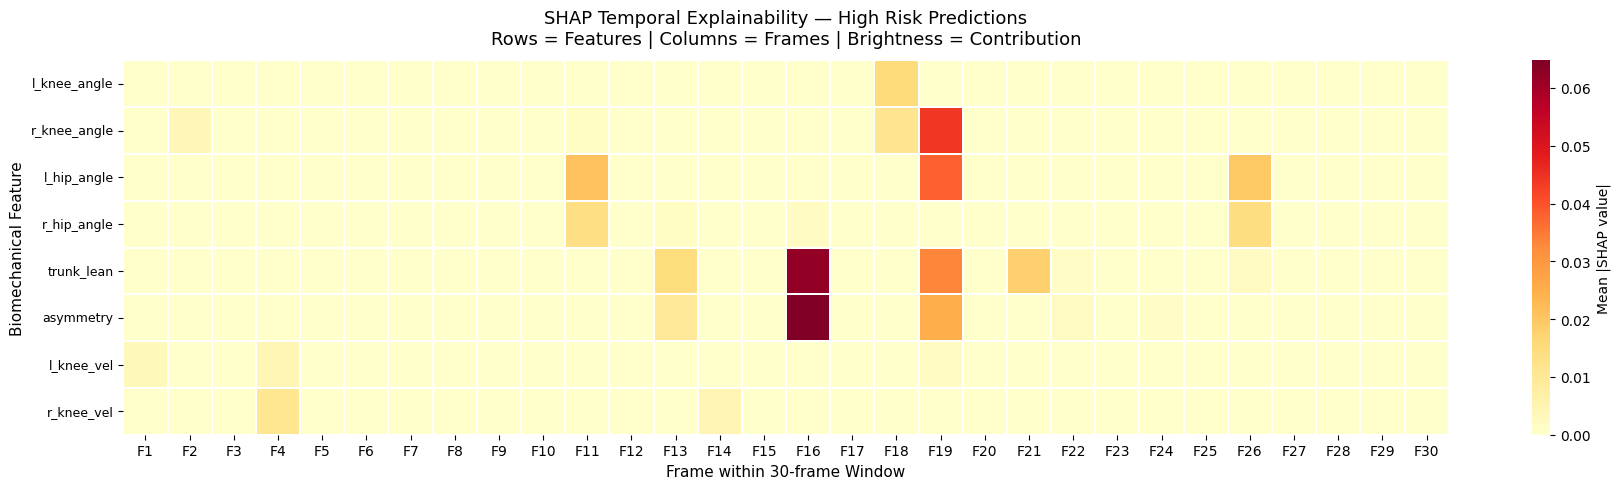

Saved: shap_temporal_heatmap.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(18, 5))

sns.heatmap(
    mean_shap.T,                     # transpose to (8 features × 30 frames)
    ax=ax,
    cmap='YlOrRd',
    xticklabels=[f'F{i+1}' for i in range(WINDOW_SIZE)],
    yticklabels=FEATURE_NAMES,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Mean |SHAP value|'}
)

ax.set_title('SHAP Temporal Explainability — High Risk Predictions\n'
             'Rows = Features | Columns = Frames | Brightness = Contribution',
             fontsize=13, pad=12)
ax.set_xlabel('Frame within 30-frame Window', fontsize=11)
ax.set_ylabel('Biomechanical Feature',         fontsize=11)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'shap_temporal_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_temporal_heatmap.png")


Feature Importance Ranking (High Risk class):
------------------------------------------
  1. trunk_lean          0.004398
  2. asymmetry           0.003435
  3. l_hip_angle         0.002617
  4. r_knee_angle        0.002043
  5. r_hip_angle         0.001047
  6. r_knee_vel          0.000535
  7. l_knee_angle        0.000508
  8. l_knee_vel          0.000310


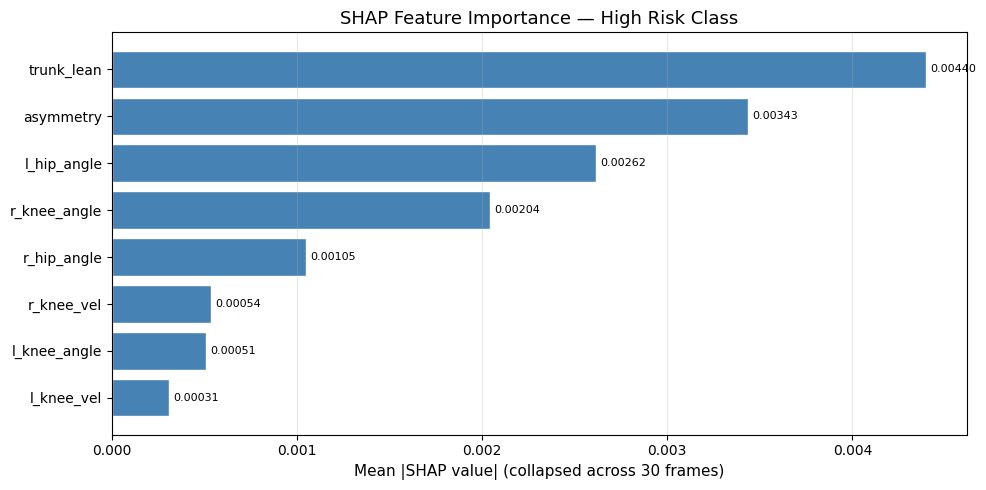

Saved: shap_feature_importance_bar.png
Saved: shap_feature_importance.csv


In [13]:
# Collapse across all 30 frames → mean importance per feature
feature_importance = mean_shap.mean(axis=0)   # shape (8,)

# Rank and print
ranked_idx = np.argsort(feature_importance)[::-1]
print("\nFeature Importance Ranking (High Risk class):")
print("-" * 42)
for rank, idx in enumerate(ranked_idx, 1):
    print(f"  {rank}. {FEATURE_NAMES[idx]:<18}  {feature_importance[idx]:.6f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
sorted_names   = [FEATURE_NAMES[i] for i in ranked_idx]
sorted_values  = feature_importance[ranked_idx]

bars = ax.barh(sorted_names[::-1], sorted_values[::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (collapsed across 30 frames)', fontsize=11)
ax.set_title('SHAP Feature Importance — High Risk Class', fontsize=13)
ax.bar_label(bars, fmt='%.5f', padding=3, fontsize=8)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'shap_feature_importance_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_feature_importance_bar.png")

# CSV
import pandas as pd
imp_df = pd.DataFrame({
    'feature'          : [FEATURE_NAMES[i] for i in ranked_idx],
    'mean_shap_importance': sorted_values
})
imp_df.to_csv(os.path.join(OUT_DIR, 'shap_feature_importance.csv'), index=False)
print("Saved: shap_feature_importance.csv")

In [14]:
outputs_6e = [
    'shap_temporal_heatmap.png',
    'shap_feature_importance_bar.png',
    'shap_feature_importance.csv'
]

print("=" * 45)
print("PHASE 6E OUTPUT FILES")
print("=" * 45)
for fname in outputs_6e:
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<42}  {size_kb:>7.1f} KB")
    else:
        print(f"  {fname:<42}  NOT FOUND")

print("\nPhase 6E complete.")

PHASE 6E OUTPUT FILES
  shap_temporal_heatmap.png                      84.0 KB
  shap_feature_importance_bar.png                61.4 KB
  shap_feature_importance.csv                     0.3 KB

Phase 6E complete.
